In [6]:
!pip install opencv-python pixellib  # 영상을 위한 opencv 라이브러리 설치

In [2]:
# 라이브러리 임포트 및 버전확인
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.13.0


원본 고양이 이미지 크기: (148, 222, 3)
배경(사막) 이미지 크기: (148, 270, 3)


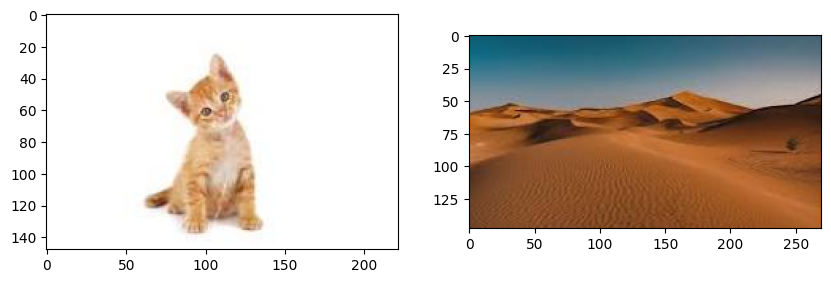

In [4]:
# 이미지 파일 경로 및 시각화
cat_img_path = "cat.jpg"  # 고양이 이미지를 준비해주세요
sand_img_path = "sand.jpg"  # 사막 배경 이미지를 준비해주세요

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [9]:
# 이미지 분할 추론
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [10]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (148, 222)


In [11]:
# ID 목록 확인
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [ 0 12 13]


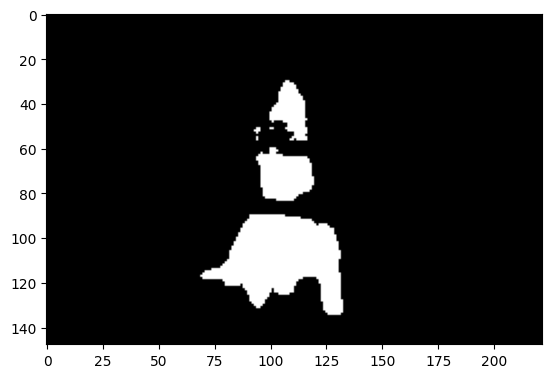

In [24]:
# 마스크 만들기
target_class_id = unique_classes[-2]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

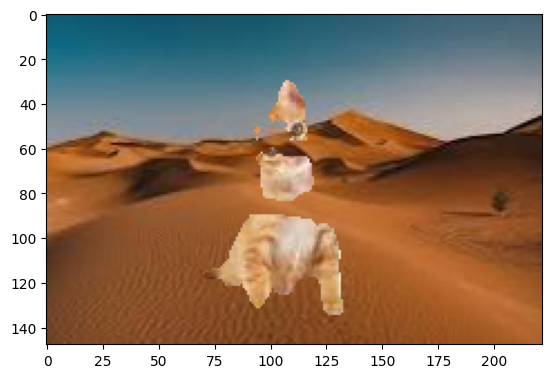

In [25]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

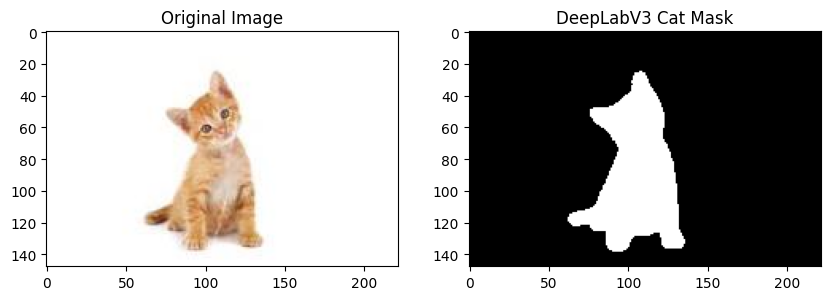

In [26]:
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Pretrained DeepLabV3 모델 및 변환 설정 로드
weights = DeepLabV3_ResNet101_Weights.DEFAULT
model = deeplabv3_resnet101(weights=weights).eval()
preprocess = weights.transforms()

# 2. 이미지 불러오기 (cat.jpg 사용)
img_path = 'cat.jpg'
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. 모델 입력을 위한 전처리 및 추론
input_tensor = preprocess(torch.from_numpy(img_rgb).permute(2, 0, 1)).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)['out'][0]

output_predictions = output.argmax(0).numpy()

# 4. COCO 데이터셋 기준 고양이 클래스 ID = 8
cat_class_id = 8
mask = (output_predictions == cat_class_id).astype(np.uint8) * 255

# 원본 이미지 크기에 맞게 마스크 리사이즈
mask_resized = cv2.resize(mask, (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)

# 5. 결과 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_rgb)

plt.subplot(1, 2, 2)
plt.title("DeepLabV3 Cat Mask")
plt.imshow(mask_resized, cmap='gray')
plt.show()

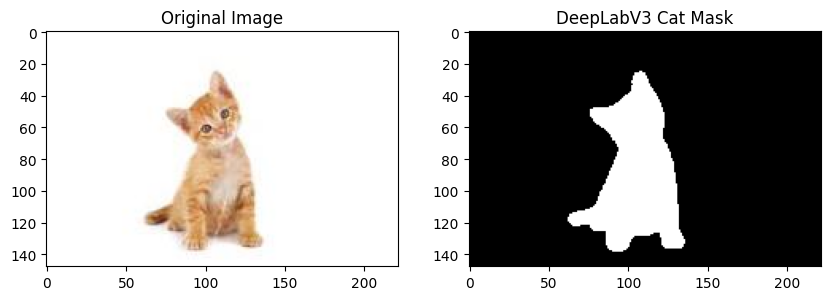

In [29]:
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Pretrained DeepLabV3 모델 및 변환 설정 로드
weights = DeepLabV3_ResNet101_Weights.DEFAULT
model = deeplabv3_resnet101(weights=weights).eval()
preprocess = weights.transforms()

# 2. 이미지 불러오기 (cat.jpg 사용)
img_path = 'cat.jpg'
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. 모델 입력을 위한 전처리 및 추론
input_tensor = preprocess(torch.from_numpy(img_rgb).permute(2, 0, 1)).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)['out'][0]

output_predictions = output.argmax(0).numpy()

# 4. COCO 데이터셋 기준 고양이 클래스 ID = 8
cat_class_id = 8
mask = (output_predictions == cat_class_id).astype(np.uint8) * 255

# 원본 이미지 크기에 맞게 마스크 리사이즈
mask_resized = cv2.resize(mask, (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)

# 5. 결과 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_rgb)

plt.subplot(1, 2, 2)
plt.title("DeepLabV3 Cat Mask")
plt.imshow(mask_resized, cmap='gray')
plt.show()

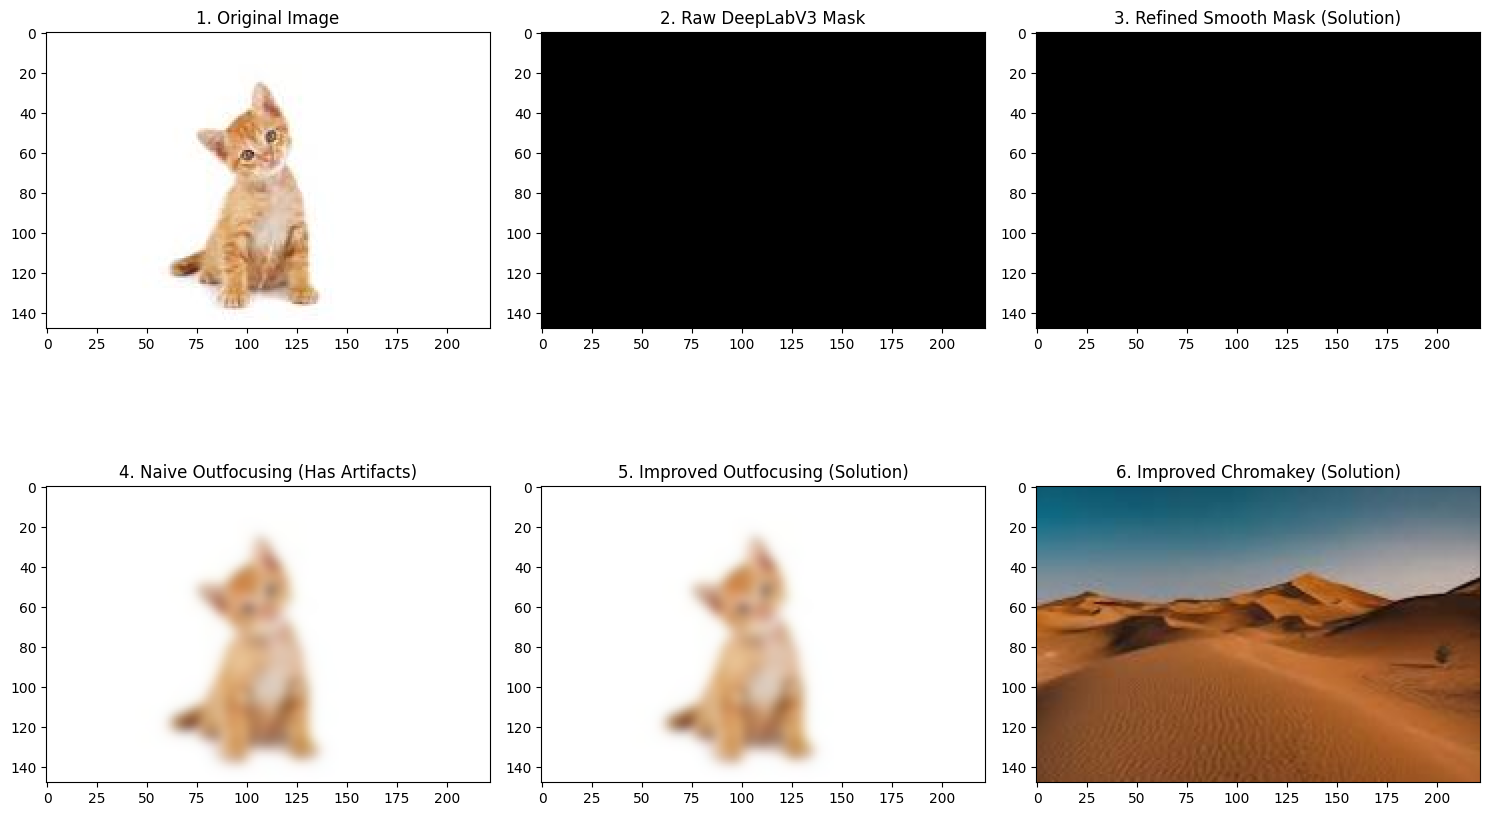

In [30]:
import cv2
import numpy as np
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

# ==========================================
# 1. 이미지 및 모델 준비 (DeepLabV3)
# ==========================================
# 파일 경로 (본인의 파일 경로로 수정하세요)
cat_img_path = 'cat.jpg'
sand_img_path = 'sand.jpg'

# 이미지 로드 (BGR -> RGB)
img_bgr = cv2.imread(cat_img_path)
sand_bgr = cv2.imread(sand_img_path)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
sand_rgb = cv2.cvtColor(sand_bgr, cv2.COLOR_BGR2RGB)

# 배경 이미지(모래)를 원본 고양이 이미지 크기에 맞게 리사이즈
sand_resized = cv2.resize(sand_rgb, (img_rgb.shape[1], img_rgb.shape[0]))

# DeepLabV3 모델 로드 및 마스크 추론
weights = torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
model = torchvision.models.segmentation.deeplabv3_resnet101(weights=weights).eval()
preprocess = weights.transforms()

input_tensor = preprocess(torch.from_numpy(img_rgb).permute(2, 0, 1)).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)['out'][0]
output_predictions = output.argmax(0).numpy()

# COCO 데이터셋 기준 Cat class id = 15
cat_mask = (output_predictions == 15).astype(np.uint8) * 255
mask_resized = cv2.resize(cat_mask, (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)

# ==========================================
# 2. 문제점 분석 (기존 방식의 아웃포커싱 & 크로마키)
# ==========================================
# 배경 아웃포커싱 (가우시안 블러)
img_blurred = cv2.GaussianBlur(img_rgb, (15, 15), 0)

# 기존 단순 마스크 적용 결과 (경계선 오차 및 경계 찌그러짐 발생)
mask_3d = np.stack([mask_resized]*3, axis=-1) / 255.0
naive_outfocus = (img_rgb * mask_3d + img_blurred * (1 - mask_3d)).astype(np.uint8)
naive_chromakey = (img_rgb * mask_3d + sand_resized * (1 - mask_3d)).astype(np.uint8)

# ==========================================
# 3. [솔루션] Semantic Segmentation Mask 오류 보완
# (모폴로지 연산 + 가우시안 블러를 이용한 알파 블렌딩)
# ==========================================
# 3-1. 모폴로지 연산으로 마스크 경계 보정 및 내부 구멍 채우기
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
refined_mask = cv2.morphologyEx(mask_resized, cv2.MORPH_CLOSE, kernel)  # 구멍 채우기
refined_mask = cv2.morphologyEx(refined_mask, cv2.MORPH_OPEN, kernel)   # 노이즈 제거

# 3-2. 알파 블렌딩용 부드러운 경계(Feathering) 생성
smooth_mask = cv2.GaussianBlur(refined_mask.astype(float), (15, 15), 0) / 255.0
smooth_mask_3d = np.stack([smooth_mask]*3, axis=-1)

# 3-3. 개선된 아웃포커싱 및 배경 전환(크로마키) 결과
sol_outfocus = (img_rgb * smooth_mask_3d + img_blurred * (1 - smooth_mask_3d)).astype(np.uint8)
sol_chromakey = (img_rgb * smooth_mask_3d + sand_resized * (1 - smooth_mask_3d)).astype(np.uint8)

# ==========================================
# 4. 결과 시각화
# ==========================================
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("1. Original Image")
plt.imshow(img_rgb)

plt.subplot(2, 3, 2)
plt.title("2. Raw DeepLabV3 Mask")
plt.imshow(mask_resized, cmap='gray')

plt.subplot(2, 3, 3)
plt.title("3. Refined Smooth Mask (Solution)")
plt.imshow(smooth_mask, cmap='gray')

plt.subplot(2, 3, 4)
plt.title("4. Naive Outfocusing (Has Artifacts)")
plt.imshow(naive_outfocus)

plt.subplot(2, 3, 5)
plt.title("5. Improved Outfocusing (Solution)")
plt.imshow(sol_outfocus)

plt.subplot(2, 3, 6)
plt.title("6. Improved Chromakey (Solution)")
plt.imshow(sol_chromakey)

plt.tight_layout()
plt.show()

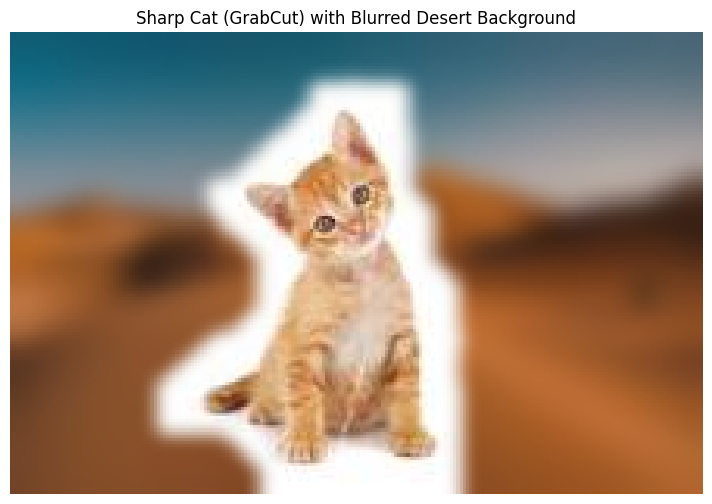

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. 파일 경로 지정 (사용하시는 이미지 경로로 확인/수정해주세요)
# ----------------------------------------------------
cat_img_path = 'cat.jpg'
sand_img_path = 'sand.jpg'

# 이미지 로드 (BGR -> RGB)
img_bgr = cv2.imread(cat_img_path)
sand_bgr = cv2.imread(sand_img_path)

if img_bgr is None or sand_bgr is None:
    raise FileNotFoundError("이미지 파일을 찾을 수 없습니다. 경로를 확인해주세요.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
sand_rgb = cv2.cvtColor(sand_bgr, cv2.COLOR_BGR2RGB)

# ----------------------------------------------------
# 2. GrabCut 알고리즘으로 고양이 영역 분리
# ----------------------------------------------------
mask = np.zeros(img_rgb.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# 고양이가 포함된 사각형 영역 지정 (x, y, width, height)
# 이미지의 전체 영역을 지정하여 알고리즘이 배경과 전경을 학습하도록 함
rect = (1, 1, img_rgb.shape[1]-1, img_rgb.shape[0]-1)

cv2.grabCut(img_rgb, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# 확실한 전경(1)과 아마도 전경(3) 영역만 추출
cat_mask = np.where((mask == 1) | (mask == 3), 255, 0).astype('uint8')

# ----------------------------------------------------
# 3. 마스크 경계 보정 (모폴로지 연산 + 가우시안 블러 알파 채널)
# ----------------------------------------------------
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
refined_mask = cv2.morphologyEx(cat_mask, cv2.MORPH_CLOSE, kernel)
refined_mask = cv2.morphologyEx(refined_mask, cv2.MORPH_OPEN, kernel)

# Alpha 채널 생성 (0.0 ~ 1.0) 및 경계 페더링(Feathering)
alpha = cv2.GaussianBlur(refined_mask.astype(float), (15, 15), 0) / 255.0
alpha_3d = np.stack([alpha] * 3, axis=-1)

# ----------------------------------------------------
# 4. 배경 이미지(사막)를 고양이 이미지 크기에 맞추고 가우시안 블러 처리
# ----------------------------------------------------
sand_resized = cv2.resize(sand_rgb, (img_rgb.shape[1], img_rgb.shape[0]))
sand_blurred = cv2.GaussianBlur(sand_resized, (25, 25), 0)

# ----------------------------------------------------
# 5. 최종 합성 (고양이: GrabCut / 배경: 사막 블러)
# ----------------------------------------------------
final_result = (img_rgb * alpha_3d + sand_blurred * (1 - alpha_3d)).astype(np.uint8)

# ----------------------------------------------------
# 6. 결과 출력
# ----------------------------------------------------
plt.figure(figsize=(10, 6))
plt.imshow(final_result)
plt.title("Sharp Cat (GrabCut) with Blurred Desert Background")
plt.axis('off')
plt.show()

세그멘테이션 마스크의 경계가 거칠거나 내부가 비어 있는 문제가 있으며, 이는 배경 합성시 부자연스러운 결과를 보여준다.

이를 해결하기 위해 모폴로지 연산으로 마스크의 구멍을 메우고 경계를 부드럽게 다듬거나, Mask R- CNN 같은 더 정밀한 세그멘테이션 모델을 사용하는 방법을 사용.


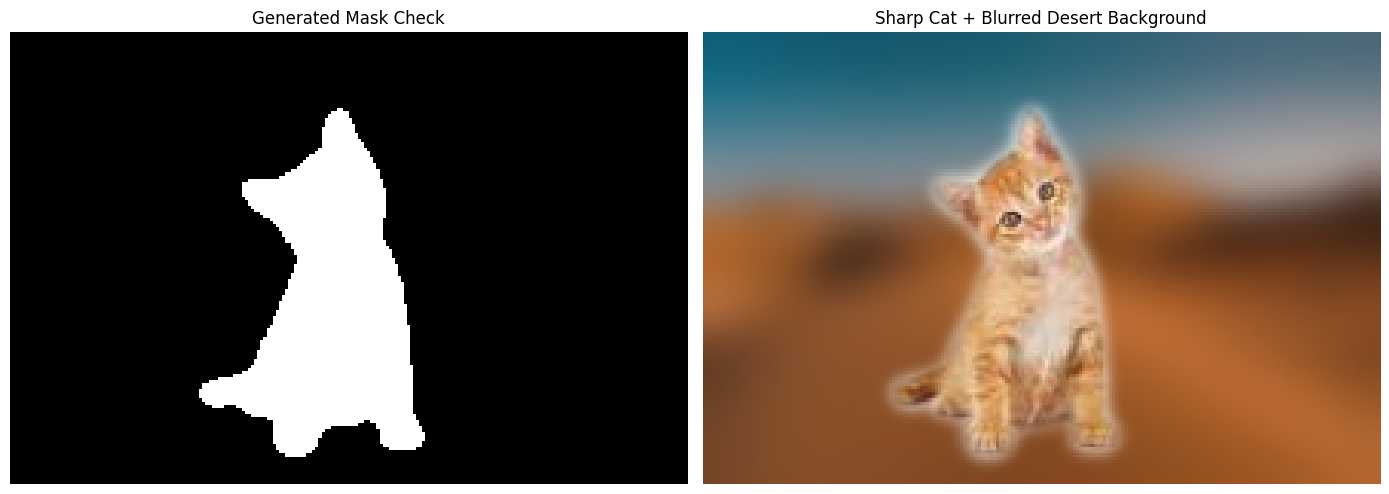

In [32]:
import cv2
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. 파일 경로 지정 (실제 파일 이름에 맞춰 수정하세요)
# ----------------------------------------------------
cat_img_path = 'cat.jpg'
sand_img_path = 'sand.jpg'

# 이미지 로드 (BGR -> RGB)
img_bgr = cv2.imread(cat_img_path)
sand_bgr = cv2.imread(sand_img_path)

if img_bgr is None or sand_bgr is None:
    raise FileNotFoundError("이미지 파일을 찾을 수 없습니다. 파일 경로를 확인해주세요.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
sand_rgb = cv2.cvtColor(sand_bgr, cv2.COLOR_BGR2RGB)

# ----------------------------------------------------
# 2. 사막 배경 리사이즈 및 강한 블러(아웃포커싱) 처리
# ----------------------------------------------------
sand_resized = cv2.resize(sand_rgb, (img_rgb.shape[1], img_rgb.shape[0]))
# 블러 강도를 높이기 위해 (45, 45) 적용
sand_blurred = cv2.GaussianBlur(sand_resized, (45, 45), 0)

# ----------------------------------------------------
# 3. DeepLabV3 모델 로드 및 추론
# ----------------------------------------------------
weights = torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
model = torchvision.models.segmentation.deeplabv3_resnet101(weights=weights).eval()
preprocess = weights.transforms()

# 이미지 전처리
input_tensor = preprocess(torch.from_numpy(img_rgb).permute(2, 0, 1)).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)['out'][0]
output_predictions = output.argmax(0).numpy()

# ----------------------------------------------------
# 4. 마스크 추출 (Pascal VOC 기준: Cat = 8, COCO 기준: Cat = 15)
# 안전하게 고양이 객체 클래스 추출
# ----------------------------------------------------
cat_class_id = 15 if 15 in output_predictions else 8  # 모델 백본에 따라 8 또는 15
cat_mask = (output_predictions == cat_class_id).astype(np.uint8) * 255

# 원본 크기로 마스크 맞추기
mask_resized = cv2.resize(cat_mask, (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)

# 만약 마스크가 비어있다면 오류 출력
if mask_resized.max() == 0:
    print("⚠️ 경고: 고양이 영역을 감지하지 못했습니다. Class ID를 재확인하세요.")

# ----------------------------------------------------
# 5. [솔루션] 모폴로지 연산 + 알파 채널 부드러운 경계 처리
# ----------------------------------------------------
# 구멍 메우기 및 외곽선 정리
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
refined_mask = cv2.morphologyEx(mask_resized, cv2.MORPH_CLOSE, kernel)
refined_mask = cv2.morphologyEx(refined_mask, cv2.MORPH_OPEN, kernel)

# Alpha 채널 생성 (0.0 ~ 1.0) 및 경계 페더링(Feathering)
alpha = cv2.GaussianBlur(refined_mask.astype(float), (15, 15), 0) / 255.0
alpha_3d = np.stack([alpha] * 3, axis=-1)

# ----------------------------------------------------
# 6. 최종 합성 (고양이: 선명 / 배경: 사막 블러)
# ----------------------------------------------------
final_result = (img_rgb * alpha_3d + sand_blurred * (1 - alpha_3d)).astype(np.uint8)

# ----------------------------------------------------
# 7. 시각화 (마스크 확인용 Subplot 포함)
# ----------------------------------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.title("Generated Mask Check")
plt.imshow(refined_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Sharp Cat + Blurred Desert Background")
plt.imshow(final_result)
plt.axis('off')

plt.tight_layout()
plt.show()